# Equilibrium Checking

Taking the eq log and dump files to determine if the chains have fully equilibrated.

The intended run is something like: equilibrate, check equilibration, production run. Ideally, after I figure out what being eq'ed entails, I can just add automatic checks with some kind of post-simulation reporting, as everything is meant to just run on the cluster without my supervision and input.

There are a couple ways to examine equilibration. Some depend on the entire run (or some chunk of it) and some only require snapshots. The snapshots are pretty easy to examine, a single frame of simulation barely takes space to store and compute, but taking the entire simulation will depend a bit on what is being used. 

For some quantities, the resolution does not matter too much and we can use far less frames (10000+ timesteps per frame), but using 100 steps per frame and a total runtime of ~2 million time steps will in fact use ~60 gb of storage. It quickly becomes prohibitive. However, despite my lack of realization, it really doesn't take that many frames, we can almost certainly get away with >1000 timesteps per frame for anything that doesn't require calculating derivatives.

## Decay timescale

This will be highly variable depending on the eq setup, so fields will be left pretty adjustable. The main idea is, for a long period of eq, checking the decay curve of the thermal quantities to figure out a total time scale. This is particularly for the NVE + lj/cut runs. Also, pick the most obvious parts of the curve, like the first chunk, as if they get too flat statistical noise will dominate. 

Workflow:
1. Check log files to figure out where to start and end reading. 
    1. The starting and ending lines just have to be within the region of numbers, the column names are not read from the file and any viable region works.
    2. There are sometimes spikes or jumps at the beginning of eq chunks, make sure the whole region being looked at is just the exponential decay.
2. Note that the column names may be different if we decide to change what thermo is logging, double check the actual log file columns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

starting_line = 172
ending_line = 472578
thermo_columns = ["Step", "Temp", "E_pair", "E_mol", "TotEng", "Press", "Pxy", "c_temp_com"]
thermo_choice = "Temp"
tolerance = 0.01

f = "logs/log.prod_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125"
df = pd.read_csv(f,
                 skiprows=starting_line-1,
                 nrows=ending_line-starting_line+1, 
                 delimiter=r'\s+', 
                 skipinitialspace=True, 
                 index_col=None, 
                 names=thermo_columns)

df["Step"] -= df["Step"][0] # set the timestep to start at 0 for fitting
display(df.head())
# plt.clf()
# plt.plot(df["Step"], df[thermo_choice])
# plt.grid()
# plt.show()

,Step,Temp,E_pair,E_mol,TotEng,Press,Pxy,c_temp_com
0,0,0.992291,0.464830,20.014789,21.967994,4.973281,0.061722,0.992271
1,100,0.999869,0.466368,20.001864,21.967973,4.979441,-0.032511,0.999849
2,200,0.997726,0.459213,20.012261,21.968000,4.997623,0.088594,0.997706
3,300,0.998429,0.457973,20.012430,21.967983,4.937443,0.014380,0.998409
4,400,0.995400,0.465580,20.009426,21.968044,5.006075,0.014333,0.995380


Fitted parameters: A=0.3076672382622931, tau=291061997.01206434, C=0.6882708629975179
Fit error (covariance): [[ 2.42605894e-05  2.11861400e+04 -2.43138320e-05]
 [ 2.11861400e+04  1.85082217e+13 -2.12319735e+04]
 [-2.43138320e-05 -2.12319735e+04  2.43672781e-05]]


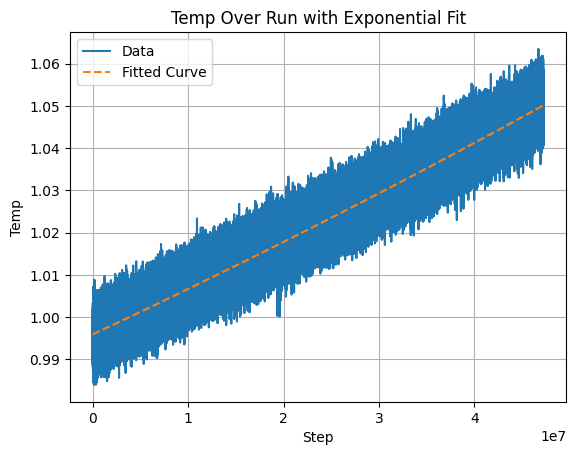

Thermo quantity: Temp
Estimated equilibration timescale (tau): 291061997.01 steps
Estimated equilibrium value (C): 0.6883
Expected time to reach tolerance of 0.01: nan steps


/tmp/ipykernel_697997/3050487175.py:25: RuntimeWarning: invalid value encountered in log
  print(f"Expected time to reach tolerance of {tolerance}: {(tau * np.log(A / (tolerance-C))):.0f} steps")


In [2]:
# fit exponential decay to thermo curve

from scipy.optimize import curve_fit

model = lambda t, A, tau, C: A * np.exp(t / tau) + C

popt, pcov = curve_fit(model, df["Step"], df[thermo_choice], p0=(0, 3000000, 1))
A, tau, C = popt
print(f"Fitted parameters: A={A}, tau={tau}, C={C}")
print(f"Fit error (covariance): {pcov}")

plt.clf()
plt.plot(df["Step"], df[thermo_choice], label="Data")
plt.plot(df["Step"], model(df["Step"], *popt), label="Fitted Curve", linestyle="--")
plt.xlabel("Step")
plt.ylabel(thermo_choice)
plt.grid()
plt.title(f"{thermo_choice} Over Run with Exponential Fit")
plt.legend()
plt.show()

print(f"Thermo quantity: {thermo_choice}")
print(f"Estimated equilibration timescale (tau): {tau:.2f} steps")
print(f"Estimated equilibrium value (C): {C:.4f}")
print(f"Expected time to reach tolerance of {tolerance}: {(tau * np.log(A / (tolerance-C))):.0f} steps")

## Mean Squared Internal Displacement



Taking these from dump files, we need to know how many lines are in each frame. The monomer indices are also not included, so we need to calculate these from the atom IDs and the molecule IDs.

We are specifically **NOT USING THE MOLECULE IDs**, as these are messed up by the Monte-Carlo bond swapping, which require beads on the same molecule to not have the same bond id but have ones reflecting their position. 

In [3]:
# read first 4 lines of file to get total number of atoms
with open("data/dumps/prod_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.lammpstrj", 'r') as f:
    header = [next(f) for _ in range(4)]
    for line in header:
        print(line.strip())

n_atoms = int(header[3])
print(n_atoms)

ITEM: TIMESTEP
6600000
ITEM: NUMBER OF ATOMS
24000
24000


We also need to set the chain length and box dimensions for monomer index and minimum image calculations 

In [4]:
chain_length = 30
box_size = 30.450711080358 # assuming cube box
# frames = list(range (0, 200, 10)) + list(range(200, 2000, 100))


and now we compute the MSID

In [20]:
import time

filename = "data/dumps/prod_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.lammpstrj"
# frames = list(range (0, 200, 10)) + list(range(200, 2000, 100))
frames = range(200, 5000, 100)
# frames = range (1, 200, 10)
r_arrays = []
read_timer = np.zeros(len(frames))
preproc_timer = 0
calc_timer = 0
frame_time_gap = 10000

read_start = time.time()
with open(filename, 'r') as f:  # this is a better method, read the whole file only once (O(n) instead of O(n*m) for m frames)
        for i, line in enumerate(f):
            if i == 0:
                continue
            if line.startswith("ITEM: TIMESTEP"):   # get the timestep of each frame
                current_frame = int(next(f).strip()) // frame_time_gap
                # skip next 7 lines of header
                # print("found frame", current_frame)
                for _ in range(7):
                    next(f)
                if current_frame in frames:
                    # print("reading frame", current_frame)
                    df = pd.read_csv(f,
                                        nrows=n_atoms,
                                        delimiter=r'\s+',
                                        skipinitialspace=True,
                                        index_col=None,
                                        names=["id", "type", "mol", "x", "y", "z", "ix", "iy", "iz"])
                    # print(df.head())
                    read_end = time.time()
                    read_timer[frames.index(current_frame)] = read_end - read_start

                    preproc_start = time.time()
                    df.sort_values("id", inplace=True) # sort by atom ID to get correct monomer indices
                    df["ux"] = df["x"] + df["ix"] * box_size # apply minimum image convention
                    df["uy"] = df["y"] + df["iy"] * box_size
                    df["uz"] = df["z"] + df["iz"] * box_size

                    n = np.linspace(0, n_atoms-1, n_atoms, dtype=int)
                    df["monomer_index"] = df["id"] % chain_length # calculate monomer index from atom ID and chain length
                    
                    sorted_positions = np.array([df["ux"], df["uy"], df["uz"]]).T
                    sliced_positions = np.reshape(sorted_positions, (n_atoms//chain_length, chain_length, 3)) # reshape to (n_chains, chain_length, 3)
                    preproc_end = time.time()
                    preproc_timer += (preproc_end - preproc_start)

                    calc_start = time.time()
                    r_values = []
                    for n in range(1, chain_length):
                        r2 = 0
                        for i in range(chain_length-n):
                            r_ij = sliced_positions[:, i+n, :] - sliced_positions[:, i, :] # awful naming here, good job
                            # print(r_ij.shape)
                            r2 += np.sum(np.sum(r_ij**2, axis=1)) # sum squares over x,y,z and then over all pairs
                        r2 /= (chain_length - n) * (n_atoms//chain_length) # average over all pairs and chains
                        r_values.append(r2)

                    # print("adding new r array for frame", current_frame)
                    r_arrays.append(r_values)
                    calc_end = time.time()
                    calc_timer += (calc_end - calc_start)

                read_start = time.time()
    
    # print(sliced_positions)

    # frame += 1
print(f"Average time to read frame: {read_timer.mean():.2f} seconds")
print(f"Average time to preprocess frame: {preproc_timer/len(frames):.2f} seconds")
print(f"Average time to calculate MISD for frame: {calc_timer/len(frames):.2f} seconds")


Average time to read frame: 0.01 seconds
Average time to preprocess frame: 0.00 seconds
Average time to calculate MISD for frame: 0.00 seconds


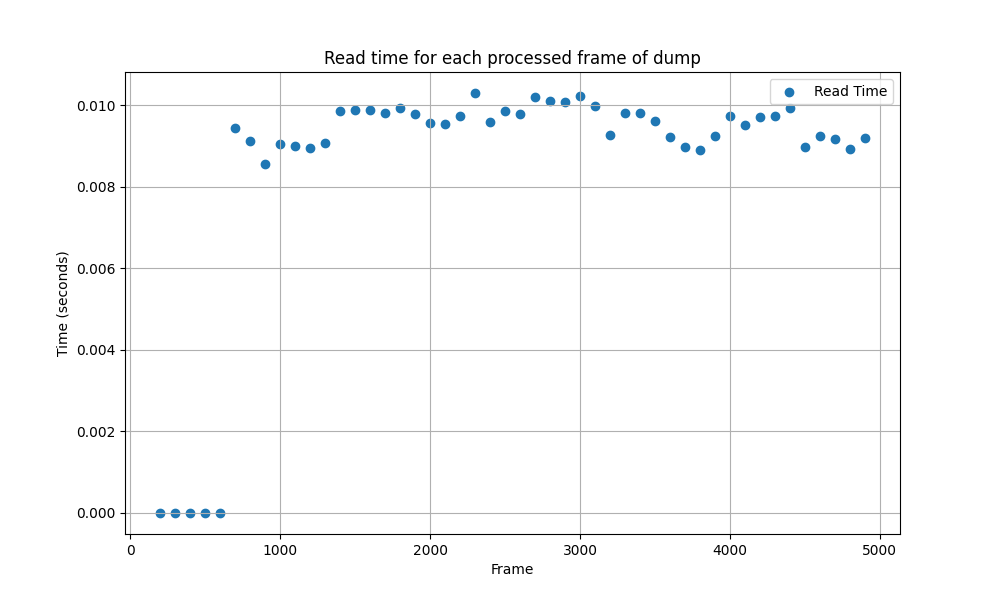

In [21]:
plt.clf()
plt.title("Read time for each processed frame of dump")
plt.scatter(frames, read_timer, label="Read Time")
plt.xlabel("Frame")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()

43
range(200, 5000, 100)
43


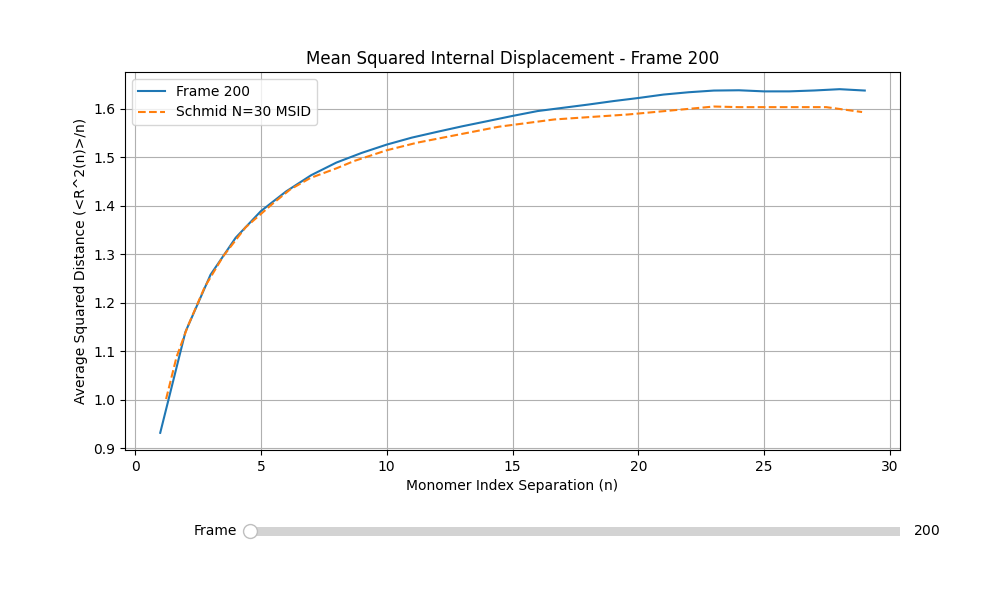

In [30]:
%matplotlib ipympl
from matplotlib.widgets import Slider

frame = frames[0]
print(len(r_arrays))

file = "data/schmid_msid_30.csv"
schmid_df = pd.read_csv(file, names=["n", "msid"])

fig, ax = plt.subplots(figsize=(10, 6))
n = np.arange(1, chain_length)
line, = ax.plot(n, r_arrays[0]/n, label=f"Frame {frames[0]}")
schmid_line, = ax.plot(schmid_df["n"], schmid_df["msid"], label="Schmid N=30 MSID", linestyle="--")   
ax.set_xlabel("Monomer Index Separation (n)")
ax.set_ylabel("Average Squared Distance (<R^2(n)>/n)")
ax.set_title(f"Mean Squared Internal Displacement - Frame {frames[0]}")
ax.grid()
ax.legend()

fig.subplots_adjust(bottom=0.25)
ax_slider = plt.axes([0.25, 0.1, 0.65, 0.03])
print(frames)
print(len(r_arrays))
frame_slider = Slider(ax=ax_slider, label="Frame", valmin=frames[0], valmax=frames[len(r_arrays)-1], valinit=frames[0], valstep=frames[0:len(r_arrays)])
def update(val):
    frame = int(frame_slider.val)
    index = frames.index(frame)
    line.set_ydata(r_arrays[index]/n)
    line.set_label(f"Frame {frame}")
    ax.legend()
    ax.set_title(f"Mean Squared Internal Displacement - Frame {frame}")
    # ax.relim()
    # ax.autoscale_view()
    fig.canvas.draw_idle()

frame_slider.on_changed(update)
plt.show()

## End-to-end distance

Should tend to a constant, we should determine what this is.

In [8]:
chain_length = 30
box_size = 30.450711080358 # assuming cube box
frames = range(2000, 50000, 100)
frame_time_gap = 10000

In [9]:
import time

filename = "data/dumps/prod_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.lammpstrj"
# frames = list(range (0, 200, 10)) + list(range(200, 2000, 100))
frames = range(200, 5000, 100)

e_e_values = []
e_e_2_values = []
e_e_4_values = []
read_frames = []
read_timer = np.zeros(len(frames))
preproc_timer = 0
calc_timer = 0

read_start = time.time()
with open(filename, 'r') as f:  # this is a better method, read the whole file only once (O(n) instead of O(n*m) for m frames)
        for i, line in enumerate(f):
            if i == 0:
                continue
            if line.startswith("ITEM: TIMESTEP"):   # get the timestep of each frame
                current_frame = int(next(f).strip()) // frame_time_gap
                # skip next 7 lines of header
                # print("found frame", current_frame)
                for _ in range(7):
                    next(f)
                if current_frame in frames:
                    # print("reading frame", current_frame)
                    df = pd.read_csv(f,
                                        nrows=n_atoms,
                                        delimiter=r'\s+',
                                        skipinitialspace=True,
                                        index_col=None,
                                        names=["id", "type", "mol", "x", "y", "z", "ix", "iy", "iz"])
                    # print(df.head())
                    read_end = time.time()
                    read_timer[frames.index(current_frame)] = read_end - read_start

                    preproc_start = time.time()
                    df.sort_values("id", inplace=True) # sort by atom ID to get correct monomer indices
                    df["ux"] = df["x"] + df["ix"] * box_size # apply minimum image convention
                    df["uy"] = df["y"] + df["iy"] * box_size
                    df["uz"] = df["z"] + df["iz"] * box_size

                    n = np.linspace(0, n_atoms-1, n_atoms, dtype=int)
                    df["monomer_index"] = df["id"] % chain_length # calculate monomer index from atom ID and chain length
                    
                    sorted_positions = np.array([df["ux"], df["uy"], df["uz"]]).T
                    sliced_positions = np.reshape(sorted_positions, (n_atoms//chain_length, chain_length, 3)) # reshape to (n_chains, chain_length, 3)
                    preproc_end = time.time()
                    preproc_timer += (preproc_end - preproc_start)

                    calc_start = time.time()
                    end_to_end = np.sqrt(np.sum((sliced_positions[:, -1, :] - sliced_positions[:, 0, :])**2, axis=1))
                    end_to_end_2 = np.sum((sliced_positions[:, -1, :] - sliced_positions[:, 0, :])**2, axis=1)
                    end_to_end_4 = np.sum((sliced_positions[:, -1, :] - sliced_positions[:, 0, :])**4, axis=1)
                    
                    e_e_values.append(np.mean(end_to_end))
                    e_e_2_values.append(np.mean(end_to_end_2))
                    e_e_4_values.append(np.mean(end_to_end_4))
                    read_frames.append(current_frame)
                    calc_end = time.time()
                    calc_timer += (calc_end - calc_start)

                read_start = time.time()
    
    # print(sliced_positions)

    # frame += 1
print(f"Average time to read frame: {read_timer.mean():.2f} seconds")
print(f"Average time to preprocess frame: {preproc_timer/len(frames):.2f} seconds")
print(f"Average time to calculate e_e for frame: {calc_timer/len(frames):.2f} seconds")


Average time to read frame: 0.01 seconds
Average time to preprocess frame: 0.00 seconds
Average time to calculate e_e for frame: 0.00 seconds


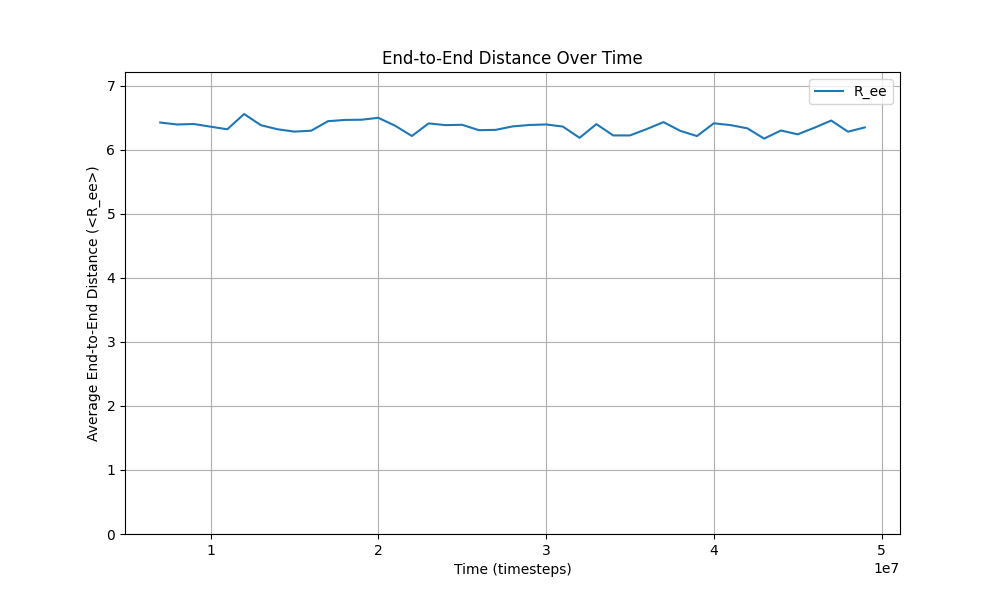

In [10]:
frame = frames[0]
# print(len(e_e_values))
fig = plt.figure(figsize=(10, 6))
plt.plot(np.array(read_frames) * frame_time_gap, e_e_values, label="R_ee")
# plt.xlim(0, frames[-1] * frame_time_gap)
plt.ylim(0, max(e_e_values)*1.1)
plt.xlabel("Time (timesteps)")
plt.ylabel("Average End-to-End Distance (<R_ee>)")
plt.title("End-to-End Distance Over Time")
plt.grid(True)
plt.legend()
plt.show()

We can use this to estimate the Kuhn length (FINALLY), using the plateau value,
$$
\langle R^2\rangle = (N-1)b^2
$$


In [11]:
# assuming plateaued, we can just use the last value to estimate Kuhn length
R2_plateau = e_e_values[-1]**2
N = chain_length
Kuhn_length = np.sqrt(R2_plateau / N)
print(f"Estimated Kuhn length: {Kuhn_length:.4f}")

Estimated Kuhn length: 1.1596


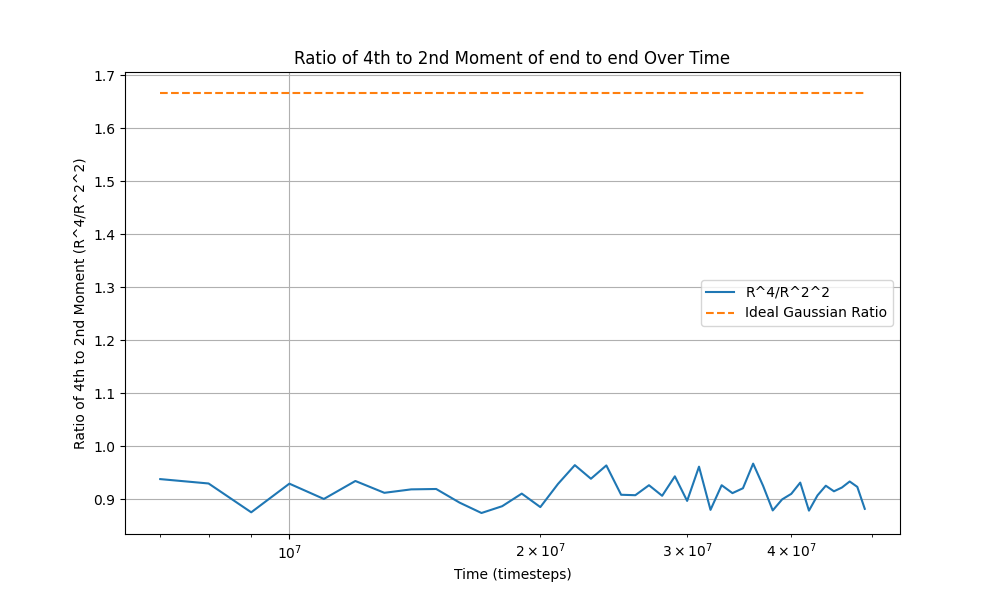

In [12]:
# ratio
ratio = np.array(e_e_4_values) / (np.array(e_e_2_values)**2)
fig = plt.figure(figsize=(10, 6))
plt.semilogx(np.array(read_frames) * frame_time_gap, ratio, label="R^4/R^2^2")
plt.semilogx(np.array(read_frames) * frame_time_gap, [5/3] * len(read_frames), label="Ideal Gaussian Ratio", linestyle="--")
plt.xlabel("Time (timesteps)")  
plt.ylabel("Ratio of 4th to 2nd Moment (R^4/R^2^2)")
plt.title("Ratio of 4th to 2nd Moment of end to end Over Time")
plt.grid()
plt.legend()
plt.show()

## Radius of gyration

Although $R_g$ is meant to be a time dependent quantity, that's only for seeing a visible trend. We don't need to do it that often to get a pretty good curve.


I did do the calculations below but the LAMMPS fix does also work, it's done on the fly and we can adjust the resolution to limit the output filesize. It's probably easier.

In [23]:
chain_length = 30
box_size = 30.450711080358 # assuming cube box
frames = range(200, 5000, 100)
frame_time_gap = 10000

In [24]:
import time

filename = "data/dumps/prod_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.lammpstrj"
# frames = list(range (0, 200, 10)) + list(range(200, 2000, 100))
# frames = range(0, 2000)

r2_g_values = []
r4_g_values = []
read_frames = []
read_timer = np.zeros(len(frames))
preproc_timer = 0
calc_timer = 0

read_start = time.time()
with open(filename, 'r') as f:  # this is a better method, read the whole file only once (O(n) instead of O(n*m) for m frames)
        for i, line in enumerate(f):
            if i == 0:
                continue
            if line.startswith("ITEM: TIMESTEP"):   # get the timestep of each frame
                current_frame = int(next(f).strip()) // frame_time_gap
                # skip next 7 lines of header
                # print("found frame", current_frame)
                for _ in range(7):
                    next(f)
                if current_frame in frames:
                    # print("reading frame", current_frame)
                    df = pd.read_csv(f,
                                        nrows=n_atoms,
                                        delimiter=r'\s+',
                                        skipinitialspace=True,
                                        index_col=None,
                                        names=["id", "type", "mol", "x", "y", "z", "ix", "iy", "iz"])
                    # print(df.head())
                    read_end = time.time()
                    read_timer[frames.index(current_frame)] = read_end - read_start

                    preproc_start = time.time()
                    df.sort_values("id", inplace=True) # sort by atom ID to get correct monomer indices
                    df["ux"] = df["x"] + df["ix"] * box_size # apply minimum image convention
                    df["uy"] = df["y"] + df["iy"] * box_size
                    df["uz"] = df["z"] + df["iz"] * box_size

                    n = np.linspace(0, n_atoms-1, n_atoms, dtype=int)
                    df["monomer_index"] = df["id"] % chain_length # calculate monomer index from atom ID and chain length
                    
                    sorted_positions = np.array([df["ux"], df["uy"], df["uz"]]).T
                    sliced_positions = np.reshape(sorted_positions, (n_atoms//chain_length, chain_length, 3)) # reshape to (n_chains, chain_length, 3)
                    preproc_end = time.time()
                    preproc_timer += (preproc_end - preproc_start)

                    calc_start = time.time()
                    coms = np.mean(sliced_positions, axis=1) # calculate center of mass for each chain
                    sliced_positions -= coms[:, np.newaxis, :] # center positions by subtracting center of mass
                    r2_g = np.sum(sliced_positions**2, axis=(1, 2)) / chain_length # calculate radius of gyration for each chain
                    r4_g = np.sum(sliced_positions**4, axis=(1, 2)) / chain_length # calculate 4th moment of radius of gyration for each chain

                    r2_g_values.append(np.mean(r2_g))
                    r4_g_values.append(np.mean(r4_g))
                    read_frames.append(current_frame)
                    calc_end = time.time()
                    calc_timer += (calc_end - calc_start)

                read_start = time.time()
    
    # print(sliced_positions)

    # frame += 1
print(f"Average time to read frame: {read_timer.mean():.2f} seconds")
print(f"Average time to preprocess frame: {preproc_timer/len(frames):.2f} seconds")
print(f"Average time to calculate R_g for frame: {calc_timer/len(frames):.2f} seconds")


Average time to read frame: 0.01 seconds
Average time to preprocess frame: 0.00 seconds
Average time to calculate R_g for frame: 0.00 seconds


43


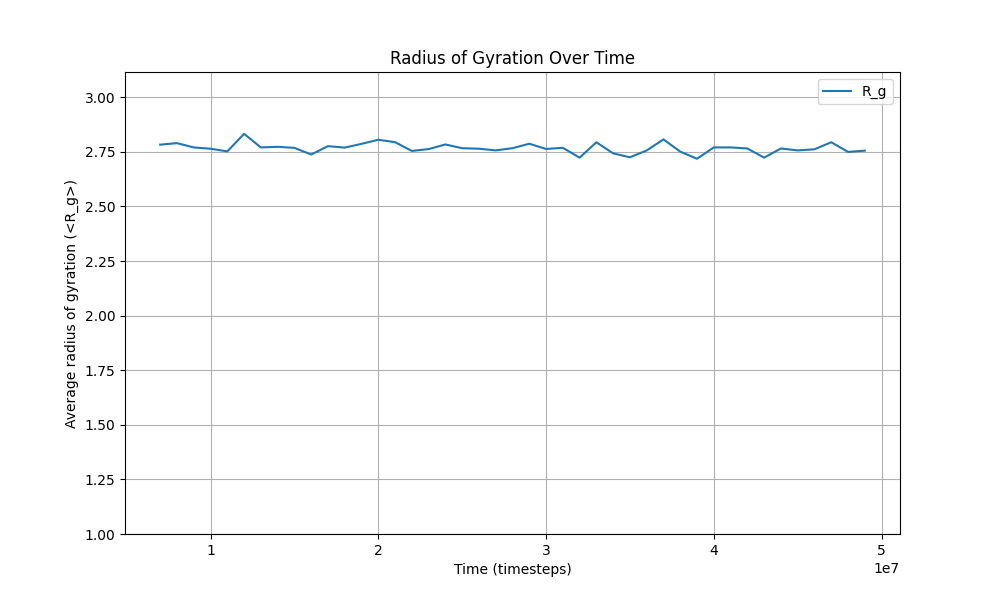

In [25]:
frame = frames[0]
print(len(r2_g_values))
fig = plt.figure(figsize=(10, 6))
plt.plot(np.array(read_frames) * frame_time_gap, np.sqrt(r2_g_values), label="R_g")
plt.xlabel("Time (timesteps)")
plt.ylabel("Average radius of gyration (<R_g>)")
plt.ylim(1, max(np.sqrt(r2_g_values)*1.1))  
plt.title("Radius of Gyration Over Time")
plt.grid()
plt.legend()
plt.show()

In [27]:
# Kuhn length, use last element of r2_g_values which should be plateaued
R2_plateau = r2_g_values[-1]
N = chain_length
kuhn_length = 6*np.sqrt(R2_plateau / (N-1)*(0.96))
print(f"Estimated Kuhn length: {kuhn_length:.4f}")

Estimated Kuhn length: 3.0083


## Radius of gyration (LAMMPS fix)

Using LAMMPS radius of gyration fix, uses molecule chunks. Will NOT work if we decide to do MC chain swapping, as monomers in one molecule will not have the same molecule id.

In [17]:
filename = "tmp.out"
# filename = "data/r_gyration.out" # TODO: the is the filename generated by LAMMPS, I still have one leftover as tmp.out but it's a gb so I can't move it
r_g_lammps = []
timesteps = []
# file consists of header
"""
# Time-averaged data for fix gyration
# TimeStep Number-of-rows
# Row c_myChunk
"""
with open(filename, 'r') as f:
    for line in f:
        if line.startswith("#"):
            # print("skipping header line")
            continue
        current_timestep, num_entries = line.strip().split() # get the timestep from the next line after the header

        # print(f"Current timestep: {current_timestep}, Number of entries: {num_entries}")
        current_timestep_r_g = np.zeros(int(num_entries))
        for i, _ in enumerate(range(int(num_entries))):
            current_timestep_r_g[i] = float(next(f).strip().split()[1]) # read the R_g value from the second column of each line
        r_g_lammps.append(current_timestep_r_g.mean()) # average over all chains for this timestep
        timesteps.append(int(current_timestep))


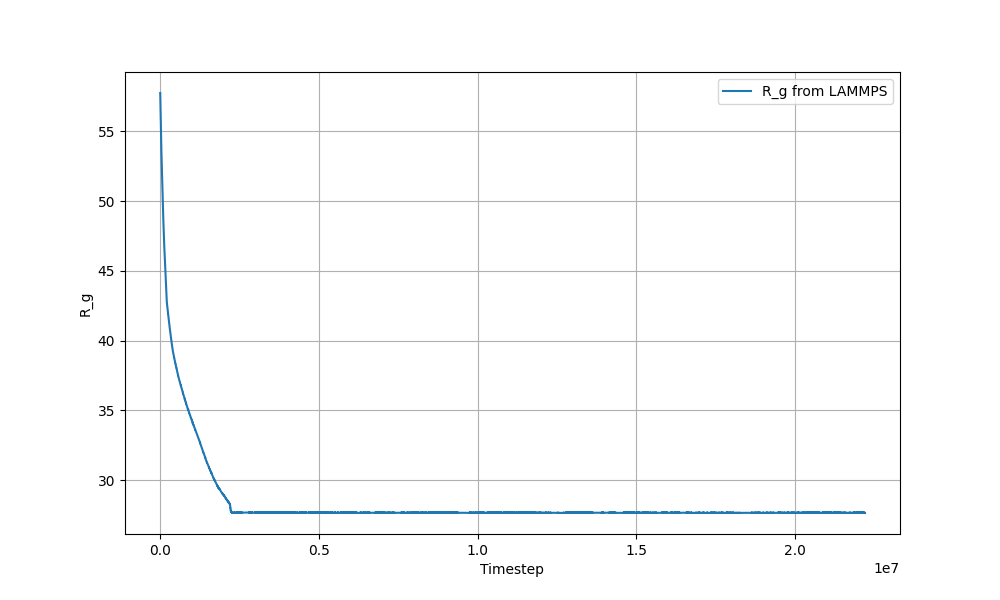

In [18]:
plt.clf()
plt.plot(timesteps, r_g_lammps, label="R_g from LAMMPS")
plt.xlabel("Timestep")
plt.ylabel("R_g")
plt.grid(True)
plt.legend()
plt.show()


In [19]:
# Kuhn length, use last element of r_g_values which should be plateaued
R2_plateau = r_g_lammps[-1]
N = chain_length
kuhn_length = np.sqrt(R2_plateau**2 / N)
print(f"Estimated Kuhn length: {kuhn_length:.4f}")

Estimated Kuhn length: 5.0524
